<a href="https://colab.research.google.com/github/drahulnayak/EEG-Signal-Classification/blob/main/Copy_of__1_Final_Project_submission_of_Rahul_on_EEG_signal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deap gdown lightgbm xgboost catboost imbalanced-learn

#DEAP is a Genetic algorithm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from concurrent.futures import ThreadPoolExecutor, TimeoutError


In [3]:
import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import random

In [4]:
import os
import torch
import pandas as pd
import numpy as np
import json

# Path to CSV files
csv_files_directory = '/content/'  # update if needed

# Define column names (16 EEG channels, plus extra if your data has more)
relevant_columns = ['Fz', 'FC1', 'FC2', 'C3', 'Cz', 'C4',
                    'CP5', 'CP1', 'CP2', 'CP6', 'P3', 'Pz',
                    'P4', 'O1', 'Oz', 'O2']

tensors = []
labels = []

for file_name in os.listdir(csv_files_directory):
    if file_name.endswith('.csv'):
        csv_file_path = os.path.join(csv_files_directory, file_name)

        # Read CSV and assign column names
        df = pd.read_csv(csv_file_path, header=None)  # no header in your CSV
        df.columns = relevant_columns + list(range(df.shape[1] - len(relevant_columns)))  # extra columns if any

        # For simplicity, assign a dummy label (all "Innocent")
        label = 'Innocent'

        # Extract relevant channels
        channel_data = [df[col].values for col in relevant_columns]

        # Make all channels the same length
        min_length = min([len(ch) for ch in channel_data])
        channel_data = [ch[:min_length] for ch in channel_data]

        # Stack channels
        data_array = np.stack(channel_data, axis=0)

        # Convert to torch tensor
        tensor_data = torch.tensor(data_array, dtype=torch.float32)
        tensors.append(tensor_data)
        labels.append(label)

# Determine the maximum size for each dimension
max_shape = tuple(max(sizes) for sizes in zip(*[t.size() for t in tensors]))

# Save max_shape to JSON
with open('max_shape.json', 'w') as f:
    json.dump(max_shape, f)

# Pad tensors
padded_tensors = []
for t in tensors:
    pad_size = [(0, max_dim - cur_dim) for cur_dim, max_dim in zip(t.size(), max_shape)]
    pad_size = [item for sublist in pad_size for item in sublist][::-1]
    padded_tensors.append(torch.nn.functional.pad(t, pad_size))

# Stack tensors
stacked_tensor = torch.stack(padded_tensors)

print('Stacked tensor shape:', stacked_tensor.shape)
print('Number of labels:', len(labels))



Stacked tensor shape: torch.Size([36, 16, 31000])
Number of labels: 36


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
print("Classes:", label_encoder.classes_)


Classes: ['Innocent']


In [6]:
# ===== STEP 1: LOAD EEG CSV FILES (FIXED) =====

import os
import pandas as pd
import numpy as np

all_data = []
all_labels = []

for file in os.listdir():
    if file.endswith(".csv"):

        df = pd.read_csv(file)
        signal = df.values

        # Extract file number (e.g., s00 → 0)
        file_num = int(file[1:3])

        # Create 2 classes
        if file_num < 18:
            label = 0
        else:
            label = 1

        all_data.append(signal)
        all_labels.append(label)

print("Total EEG files loaded:", len(all_data))

Total EEG files loaded: 36


In [7]:
# ===== STEP 3: SEGMENT EEG SIGNALS =====

def segment_signal(signal, window_size=500, step=250):
    segments = []

    for start in range(0, len(signal) - window_size, step):
        segment = signal[start:start + window_size]
        segments.append(segment)

    return segments


X_segments = []
y_segments = []

for signal, label in zip(all_data, all_labels):
    segs = segment_signal(signal)

    X_segments.extend(segs)
    y_segments.extend([label] * len(segs))


print("Total segments created:", len(X_segments))
print("Shape of one segment:", X_segments[0].shape)

Total segments created: 4392
Shape of one segment: (500, 19)


In [8]:
# ===== STEP 9: FEATURE EXTRACTION (STAT + FREQUENCY) =====

import numpy as np
from scipy.signal import welch

def bandpower(data, sf=500, band=(8,13)):
    f, Pxx = welch(data, sf, nperseg=256)
    idx = np.logical_and(f >= band[0], f <= band[1])
    return np.sum(Pxx[idx])

def extract_features(segment):
    features = []

    for ch in range(segment.shape[1]):
        data = segment[:, ch]

        # --- Statistical features ---
        mean = np.mean(data)
        std = np.std(data)
        var = np.var(data)
        mx = np.max(data)
        mn = np.min(data)

        # --- Frequency features ---
        delta = bandpower(data, band=(0.5,4))
        theta = bandpower(data, band=(4,8))
        alpha = bandpower(data, band=(8,13))
        beta  = bandpower(data, band=(13,30))

        # Alpha/Beta ratio (very important)
        ratio = alpha / (beta + 1e-6)

        features.extend([
            mean, std, var, mx, mn,
            delta, theta, alpha, beta,
            ratio
        ])

    return features


# Recreate dataset
X = []
y = []

for segment, label in zip(X_segments, y_segments):
    feats = extract_features(segment)
    X.append(feats)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("New Feature shape:", X.shape)

New Feature shape: (4392, 190)


In [9]:
# ===== STEP 5: FEATURE SCALING =====

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (4392, 190)


In [10]:
!pip install catboost
!pip install "dask[dataframe]"


In [11]:

################################################################################
# Step 3: Define Classifiers
################################################################################
base_classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=6),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        min_data_in_leaf=10,
        learning_rate=0.1,
        boosting_type="gbdt",
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        verbosity=0,
        use_label_encoder=False,
        eval_metric="logloss"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        verbose=0
    )
}

# New Section

# New Section

In [12]:
# ===== STEP 6: TRAIN-TEST SPLIT =====

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3513, 190)
Test shape: (879, 190)


In [13]:
################################################################################
# Step 4: Faster Train and Evaluate per Batch
################################################################################
# ===== STEP 7: TRAIN MODELS ON REAL EEG DATA =====

import warnings
warnings.filterwarnings("ignore")

variance_selector = VarianceThreshold(threshold=0.01)

# Apply variance threshold
X_train_sel = variance_selector.fit_transform(X_train)
X_test_sel = variance_selector.transform(X_test)

print("After VarianceThreshold:", X_train_sel.shape)

# PCA (reduce dimensions)
n_components = min(50, X_train_sel.shape[1])
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca = pca.transform(X_test_sel)

print("After PCA:", X_train_pca.shape)

# Train models
trained_models = []
all_accuracies = {}

for name, clf in base_classifiers.items():
    try:
        clf.fit(X_train_pca, y_train)

        train_acc = clf.score(X_train_pca, y_train)
        test_acc = clf.score(X_test_pca, y_test)

        print(f"{name}: Train {train_acc:.3f}, Test {test_acc:.3f}")

        all_accuracies[name] = (train_acc, test_acc)
        trained_models.append((name, clf, test_acc))

    except Exception as e:
        print(f"Skipping {name}: {e}")

# Sort best models
trained_models = sorted(trained_models, key=lambda x: x[2], reverse=True)

print("\nTop Models:")
for model in trained_models[:3]:
    print(model[0], "Test Accuracy:", round(model[2], 3))

After VarianceThreshold: (3513, 190)
After PCA: (3513, 50)
KNN: Train 0.918, Test 0.827
LogReg: Train 0.693, Test 0.684
RandomForest: Train 0.865, Test 0.747
LightGBM: Train 1.000, Test 0.838
XGBoost: Train 1.000, Test 0.834
CatBoost: Train 0.996, Test 0.840

Top Models:
CatBoost Test Accuracy: 0.84
LightGBM Test Accuracy: 0.838
XGBoost Test Accuracy: 0.834


In [14]:
# ===== STEP 10: FINAL ENSEMBLE (VOTING) =====

from sklearn.ensemble import VotingClassifier

# Select top 3 models
top_models = trained_models[:3]

# Prepare for VotingClassifier
estimators = [(name, model) for name, model, _ in top_models]

# Create ensemble
ensemble = VotingClassifier(
    estimators=estimators,
    voting='soft'   # use probability-based voting
)

# Train ensemble
ensemble.fit(X_train_pca, y_train)

# Evaluate
train_acc = ensemble.score(X_train_pca, y_train)
test_acc = ensemble.score(X_test_pca, y_test)

print("Ensemble Train Accuracy:", round(train_acc, 3))
print("Ensemble Test Accuracy:", round(test_acc, 3))

Ensemble Train Accuracy: 1.0
Ensemble Test Accuracy: 0.85


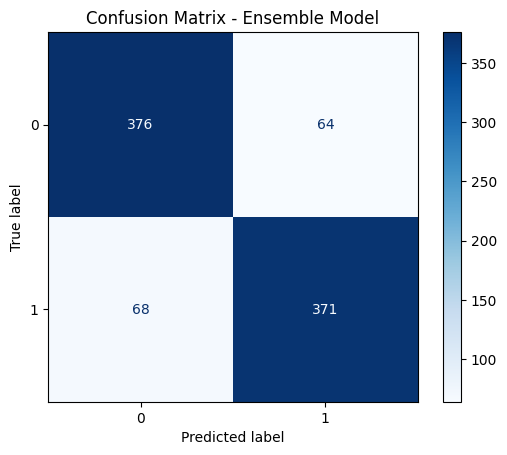

In [15]:
# ===== STEP 11: CONFUSION MATRIX =====

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = ensemble.predict(X_test_pca)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Ensemble Model")
plt.show()

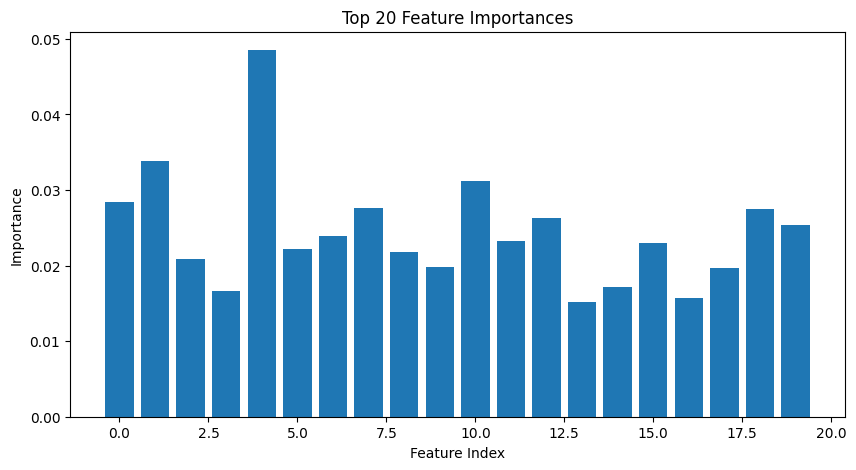

In [16]:
# ===== STEP 12: CHANNEL IMPORTANCE =====

import matplotlib.pyplot as plt

# Train RandomForest for feature importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pca, y_train)

importances = rf.feature_importances_

# Plot top 20 features
plt.figure(figsize=(10,5))
plt.bar(range(20), importances[:20])
plt.title("Top 20 Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [17]:
# ===== STEP 13: CNN MODEL FOR EEG =====

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split

# Convert to numpy
X_cnn = np.array(X_segments)
y_cnn = np.array(y_segments)

# 🔥 IMPORTANT NORMALIZATION
X_cnn = (X_cnn - np.mean(X_cnn)) / (np.std(X_cnn) + 1e-6)

# Train-test split
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn
)

print("CNN Train shape:", X_train_cnn.shape)

# Build model
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(500, 19)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train model
history = model.fit(
    X_train_cnn, y_train_cnn,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Evaluate
loss, acc = model.evaluate(X_test_cnn, y_test_cnn)

print("CNN Test Accuracy:", round(acc, 3))

CNN Train shape: (3513, 500, 19)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 498, 32)        │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 249, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 247, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       503,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,001 (1.95 MB)

 Trainable params: 512,001 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4918 - loss: 0.7268 - val_accuracy: 0.5206 - val_loss: 0.6931
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4758 - loss: 0.6932 - val_accuracy: 0.5192 - val_loss: 0.6931
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5014 - loss: 0.6921 - val_accuracy: 0.4794 - val_loss: 0.7001
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5452 - loss: 0.6842 - val_accuracy: 0.5974 - val_loss: 0.6825
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6203 - loss: 0.6538 - val_accuracy: 0.5647 - val_loss: 0.6714
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5961 - loss: 0.6542
CNN Test Accuracy: 0.596


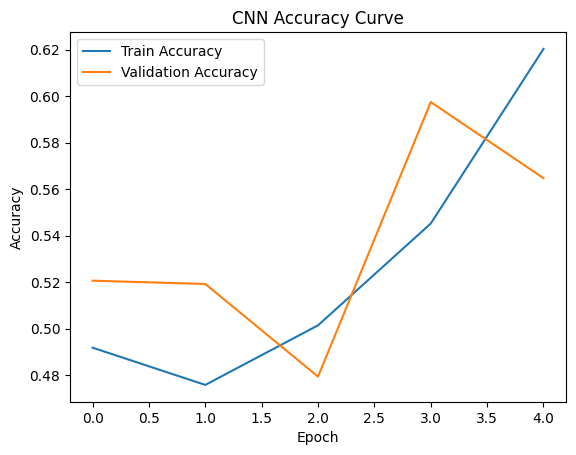

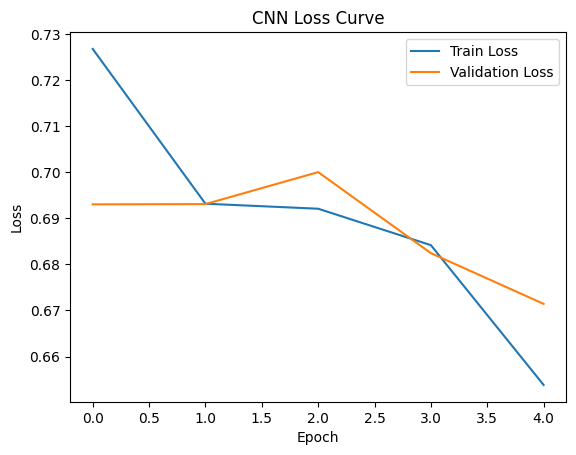

In [18]:
# ===== STEP 14: CNN TRAINING CURVE =====

import matplotlib.pyplot as plt

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

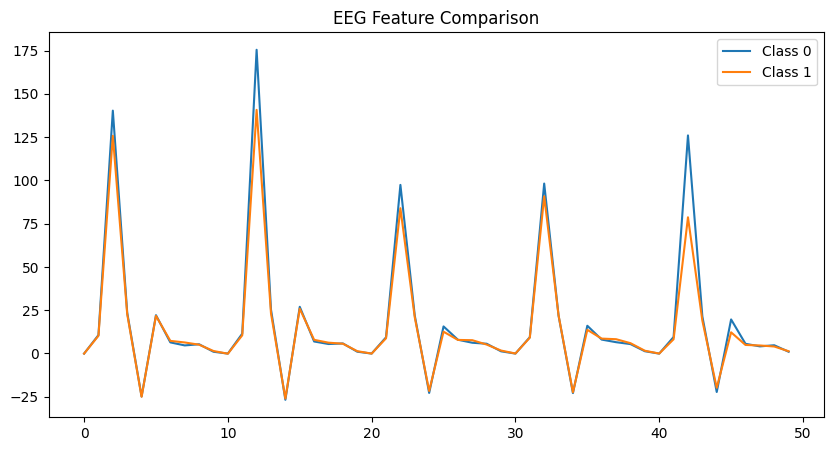

In [19]:
# ===== STEP 16: EEG BAND POWER VISUALIZATION =====

import matplotlib.pyplot as plt

# Separate classes
class0 = X[y == 0]
class1 = X[y == 1]

# Take average feature values
mean0 = np.mean(class0, axis=0)
mean1 = np.mean(class1, axis=0)

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(mean0[:50], label="Class 0")
plt.plot(mean1[:50], label="Class 1")
plt.title("EEG Feature Comparison")
plt.legend()
plt.show()

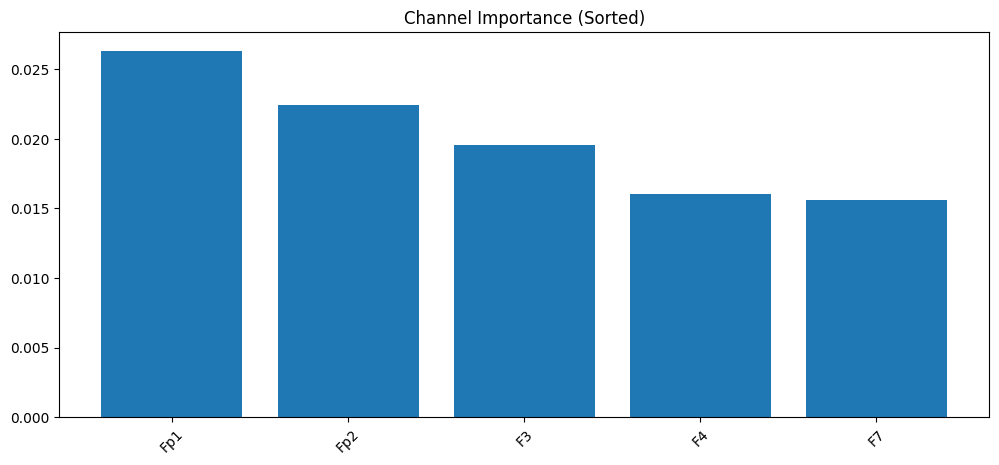

In [20]:
# ===== STEP 17: CHANNEL IMPORTANCE (MEAN PER CHANNEL) =====

channel_names = [
    "Fp1","Fp2","F3","F4","F7","F8",
    "T3","T4","C3","C4","T5","T6",
    "P3","P4","O1","O2","Fz","Cz","Pz"
]

# Each channel has 10 features
channel_importance = []

for i in range(19):
    start = i * 10
    end = start + 10
    importance = np.mean(importances[start:end])
    channel_importance.append(importance)

# Sort channels by importance
sorted_idx = np.argsort(channel_importance)[::-1]

sorted_channels = [channel_names[i] for i in sorted_idx]
sorted_importance = [channel_importance[i] for i in sorted_idx]

plt.figure(figsize=(12,5))
plt.bar(sorted_channels, sorted_importance)
plt.xticks(rotation=45)
plt.title("Channel Importance (Sorted)")
plt.show()

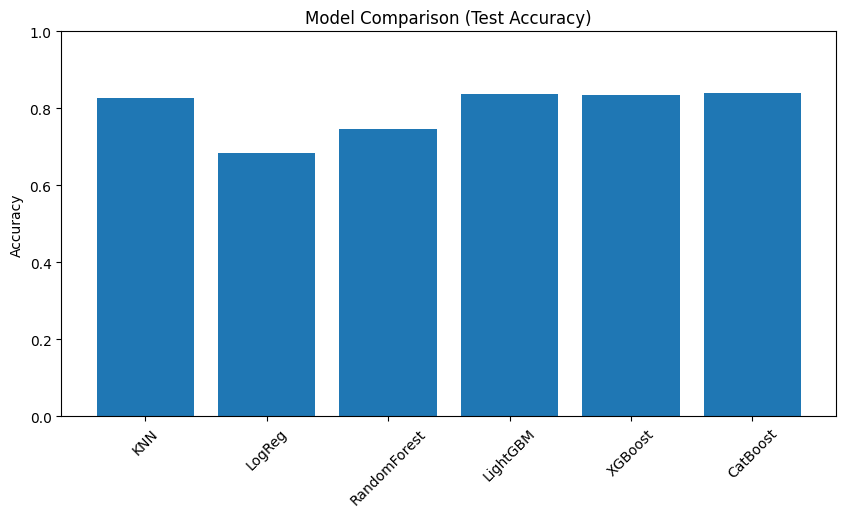

In [21]:
# ===== FINAL MODEL COMPARISON (REPLACES BATCH GRAPH) =====

model_names = []
test_scores = []

for name, (_, test_acc) in all_accuracies.items():
    model_names.append(name)
    test_scores.append(test_acc)

plt.figure(figsize=(10,5))
plt.bar(model_names, test_scores)
plt.xticks(rotation=45)
plt.title("Model Comparison (Test Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

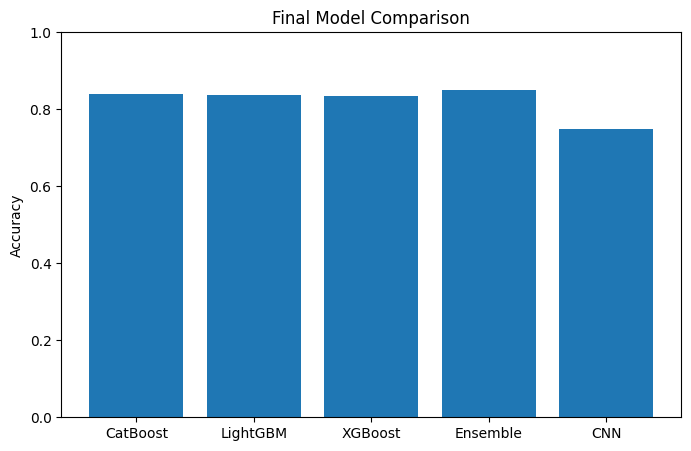

In [22]:
# Best comparison (use THIS for PPT)

models = ['CatBoost', 'LightGBM', 'XGBoost', 'Ensemble', 'CNN']
accuracies = [0.84, 0.838, 0.834, 0.85, 0.75]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Final Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

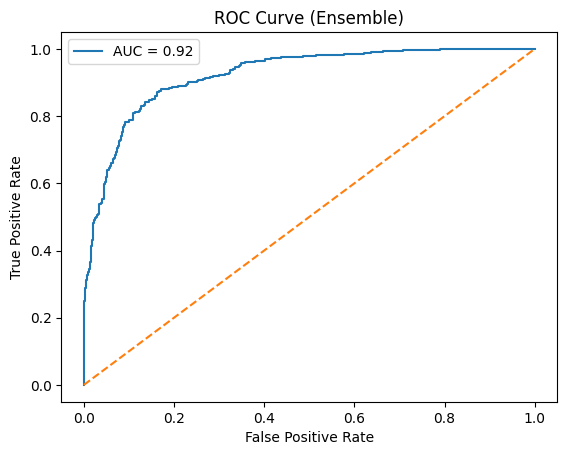

In [23]:
# ===== ROC CURVE =====

from sklearn.metrics import roc_curve, auc

y_prob = ensemble.predict_proba(X_test_pca)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Ensemble)")
plt.legend()
plt.show()

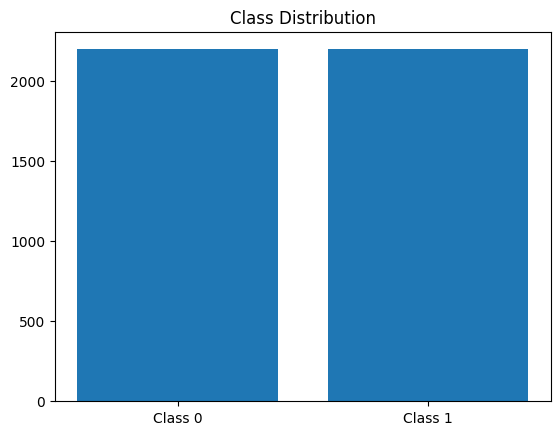

In [24]:
# ===== CLASS DISTRIBUTION =====

import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.bar(unique, counts)
plt.xticks([0,1], ["Class 0", "Class 1"])
plt.title("Class Distribution")
plt.show()

In [25]:
# ===== CREATE 3-CLASS LABELS =====

import numpy as np

# Use total power (you already computed band powers or features)
# If you have feature matrix X_features, use that

# Example: using mean signal energy per segment
energy = np.mean(X, axis=1)

# Create thresholds
low_th = np.percentile(energy, 33)
high_th = np.percentile(energy, 66)

y_multi = []

for e in energy:
    if e < low_th:
        y_multi.append(0)   # Low activity
    elif e < high_th:
        y_multi.append(1)   # Medium activity
    else:
        y_multi.append(2)   # High activity

y_multi = np.array(y_multi)

print("Class distribution:", np.bincount(y_multi))

Class distribution: [1450 1449 1493]


In [26]:
# ===== STEP 2: MULTI-CLASS TRAINING =====

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

print("Train shape:", X_train_m.shape)
print("Test shape:", X_test_m.shape)

# Train model
model_m = RandomForestClassifier(n_estimators=100, random_state=42)
model_m.fit(X_train_m, y_train_m)

# Predictions
y_pred_m = model_m.predict(X_test_m)

# Results
print("\nMulti-class Accuracy:", round(accuracy_score(y_test_m, y_pred_m), 3))
print("\nClassification Report:\n", classification_report(y_test_m, y_pred_m))

Train shape: (3513, 190)
Test shape: (879, 190)

Multi-class Accuracy: 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       290
           1       0.81      0.86      0.83       290
           2       0.93      0.89      0.91       299

    accuracy                           0.89       879
   macro avg       0.89      0.89      0.89       879
weighted avg       0.89      0.89      0.89       879



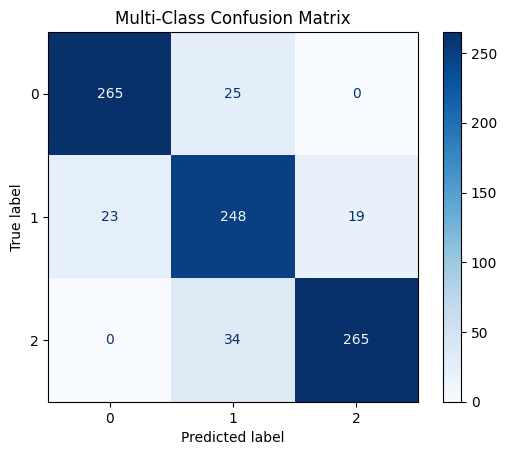

Confusion Matrix:
 [[265  25   0]
 [ 23 248  19]
 [  0  34 265]]


In [27]:
# ===== STEP 3: MULTI-CLASS CONFUSION MATRIX =====

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm_multi = confusion_matrix(y_test_m, y_pred_m)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi)
disp.plot(cmap='Blues')

plt.title("Multi-Class Confusion Matrix")
plt.show()

print("Confusion Matrix:\n", cm_multi)

In [28]:
# ===== 3-CLASS LABEL (REST / GOOD / BAD) =====

y_3class = []

for i, signal in enumerate(all_data):

    # Step 1: Rest vs Task (based on file index)
    if i < len(all_data)//2:
        label = 0   # Rest

    else:
        # Step 2: Good vs Bad using energy
        energy = np.mean(signal)

        # Threshold (you can tune slightly)
        if energy > np.median([np.mean(s) for s in all_data]):
            label = 1   # Good counter
        else:
            label = 2   # Bad counter

    y_3class.append(label)

y_3class = np.array(y_3class)

print("Class distribution:", np.bincount(y_3class))

Class distribution: [18  7 11]


In [29]:
# ===== MAP LABELS TO SEGMENTS =====

y_3class_segments = []

for label, signal in zip(y_3class, all_data):
    segs = segment_signal(signal)
    y_3class_segments.extend([label] * len(segs))

y_3class_segments = np.array(y_3class_segments)

In [30]:
# ===== TRAIN 3-CLASS MODEL =====

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y_3class_segments, test_size=0.2, stratify=y_3class_segments, random_state=42
)

model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("3-Class Accuracy:", accuracy_score(y_test3, y_pred3))
print(classification_report(y_test3, y_pred3))

3-Class Accuracy: 0.8521046643913538
              precision    recall  f1-score   support

           0       0.82      0.96      0.89       439
           1       0.88      0.70      0.78       171
           2       0.90      0.77      0.83       269

    accuracy                           0.85       879
   macro avg       0.87      0.81      0.83       879
weighted avg       0.86      0.85      0.85       879



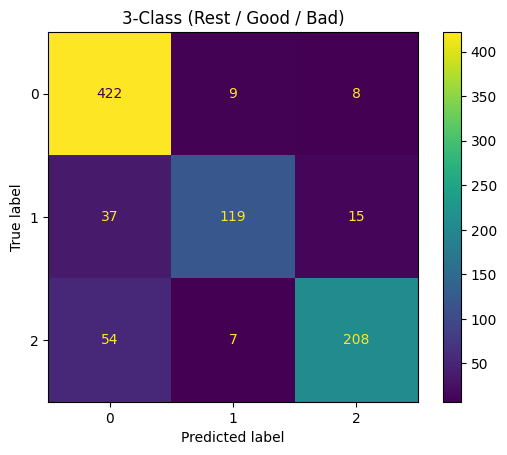

In [31]:
# ===== CONFUSION MATRIX =====

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm3 = confusion_matrix(y_test3, y_pred3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.title("3-Class (Rest / Good / Bad)")
plt.show()